# Phase 2 — Signal Preprocessing, Feature Extraction & Correlation Analysis

## Section 1: Data Quality Assessment → Preprocessing Justification

Bảng dưới đây map từng Phase 1 finding → vấn đề nó gây ra → bước preprocessing giải quyết.

## Data Quality Observations → Preprocessing Decisions

| # | Data Observation (Phase 1) | Evidence | Problem It Causes | Preprocessing Step | DAV Category |
|---|---|---|---|---|---|
| 1 | **Amplitude varies drastically across recordings** — RMS of 9979_TV (Murmur) is 7038, vs. 1165 for 2530_MV (Normal): a 6× difference. Both examples hit int16 clipping ceiling (±32768). Stethoscope pressure and patient body size both affect absolute amplitude. | Task 1.8, signal RMS values | Model receives signals on incomparable absolute scales. Features derived from raw amplitude are meaningless across patients. Clipping artifacts distort waveform shape. | **Amplitude normalisation:** subtract mean, divide by peak amplitude → output range [−1, 1], uniform across all recordings | Feature Normalisation |
| 2 | **Raw waveform encodes no frequency structure** — time-domain signal shows S1/S2 as amplitude spikes and murmur as "filled systole," but these patterns are not separable into discriminative numeric features without frequency decomposition. Heart sounds have characteristic spectral signatures (S1 ~20–150 Hz, S2 ~20–200 Hz, murmur energy ~50–400 Hz). | Task 1.8 visual inspection; cardiac acoustics literature | A 1D sequence of amplitude values cannot capture the simultaneous time and frequency information needed to distinguish S1, S2, systole, diastole, and murmur states. | **Log-spectrogram (STFT):** Hann window 50 ms, hop 20 ms → 2D time-frequency representation (101 freq bins × T frames). Transforms 1D signal into interpretable feature matrix. | Feature Transformation |
| 3 | **Heart sound energy is concentrated below ~800 Hz** — clinical literature establishes S1 (20–150 Hz), S2 (20–200 Hz), and murmurs (50–400 Hz). Frequencies above 800 Hz in PCG recordings consist of ambient noise, speech artifacts, stethoscope contact sounds, and breathing. 9983_MV (Unknown) shows prominent high-frequency noise bursts. | Task 1.8–1.9 visual inspection; paper explicit statement: "remove higher frequencies that contain no heart sound information" | Including high-frequency bins (800–2000 Hz) adds 60 noise-dominated features per time frame. The RNN risks learning spurious high-frequency correlates that do not generalise across recording conditions. | **Frequency cropping (0–800 Hz):** discard bins 41–100, retain bins 0–40 → reduces from 101 to **41 frequency bins** (59% dimensionality reduction). Validated by spectral correlation analysis in notebook 02b. | Feature Selection |
| 4 | **Murmurs are much quieter than S1/S2 in the spectrogram** — S1 and S2 heart sounds produce sharp, high-energy events visible as bright columns in the spectrogram. Murmur energy (especially Grade 1, 58% of cases) is diffuse and ~10–20 dB lower in spectral energy than S1/S2. Without equalisation, quiet murmurs are nearly invisible relative to the dominant S1/S2 events. | Task 1.7 (Grade 1 = 58% of Present); paper: "murmurs commonly contain much less time-frequency energy than S1 and S2 sounds" | The RNN sees spectrogram columns dominated by S1/S2 energy. Murmur-specific frequency patterns have near-zero relative values and may be ignored by the model — especially for Grade 1 quiet murmurs. | **Per-frequency-row z-score normalisation:** for each of the 41 frequency rows, subtract its mean and divide by its std across the time axis → each row has mean ≈ 0, std ≈ 1, making murmur-related bins equally prominent as S1/S2 bins. | Feature Normalisation |
| 5 | **Recording durations vary from 5s to 64s** — median 21.5s, but range is wide. No class differences in duration (all three classes have nearly identical duration distributions). | Task 1.6 | A fixed-size input tensor cannot accommodate variable-length recordings without truncation or padding, both of which lose information or introduce artificial patterns. | **Variable-length sequence handling:** the RNN operates frame-by-frame on the (41 × T) feature matrix regardless of T. No truncation or padding at the feature level. Batching strategy handled in Phase 3. | (Phase 3) |
| 6 | **Demographics are not predictive of murmur status** — murmur prevalence is stable at ~19% across all age groups, both sexes, and height/weight ranges. Formal correlation analysis in notebook 02b confirms all metadata–label associations are weak (Cramér's V < 0.15). | Tasks 1.4, 1.10; notebook 02b Task 2.5b | Including demographic features as model input would add noise without adding signal, and would make the pipeline less generalisable to different patient populations. | **Audio-only pipeline:** no demographic features are fed to the RNN or HSMM. This is validated by correlation analysis, not just assumed. | Feature Selection (by omission) |

## Feature Dimensionality Through the Pipeline

| Stage | Representation | Shape | DAV Step |
|---|---|---|---|
| Input | Raw PCG waveform | (N,) — e.g. 86,000 samples for 21.5s | — |
| After normalisation | Normalised waveform | (N,) — same length, float64 [−1,1] | Feature Normalisation |
| After STFT | Log-spectrogram | (101, T) — e.g. (101, 1073) | Feature Transformation |
| After frequency cropping | Cropped spectrogram | **(41, T)** — 59% of freq bins removed | Feature Selection |
| After z-score | Normalised spectrogram | **(41, T)** — same shape, each row normalised | Feature Normalisation |
| → RNN input | Final feature matrix | **(41, T)** | — |

**Net transformation:** 86,000 scalar values → 44,000 normalised feature values (at T≈1073 frames)
**Effective dimensionality reduction:** Raw waveform has 86k time-domain samples with no structure exposed. The 41×T spectrogram exposes time-frequency structure in a form the RNN can learn from. The frequency cropping step itself reduces spectral dimensionality by 59%.

## Section 2: Feature Transformation — Amplitude Normalisation

**DAV Category:** Feature Normalisation  
**Input:** Raw PCG waveform (int16, variable amplitude, sampling rate 4000 Hz)  
**Algorithm:** Zero-mean subtraction → divide by peak absolute amplitude  
**Output:** Float64 waveform, range [−1, 1], same length as input  

**Motivation (from Task 2.0, Observation 1):**  
RMS amplitude varies up to 6× across recordings (e.g. 9979_TV RMS=7038 vs. 2530_MV RMS=1165),
and both examples hit int16 clipping ceiling (±32768). Absolute amplitude is an unreliable
feature — it depends on stethoscope application pressure, not on cardiac physiology.
Normalisation puts all recordings on a comparable scale before spectrogram extraction.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import sys, os
from pathlib import Path

sys.path.insert(0, os.path.abspath(".."))
from src.features.normalisation import normalise_amplitude

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT = Path("../data/raw/training_data")

EXAMPLES = {
    "Normal (2530_MV)":  "2530_MV.wav",
    "Murmur (9979_TV)":  "9979_TV.wav",
    "Unknown (9983_MV)": "9983_MV.wav",
}

# ── Load raw int16 waveforms ───────────────────────────────────────────────────
raw_signals = {}
for label, filename in EXAMPLES.items():
    sr, data = wavfile.read(DATA_ROOT / filename)
    if data.ndim > 1:
        data = data[:, 0]
    raw_signals[label] = (sr, data)
    print(f"{label:25s}  sr={sr} Hz  shape={data.shape}  "
          f"dtype={data.dtype}  RMS={np.sqrt(np.mean(data.astype(float)**2)):.0f}  "
          f"peak={np.max(np.abs(data))}")

Normal (2530_MV)           sr=4000 Hz  shape=(106752,)  dtype=int16  RMS=1165  peak=32767
Murmur (9979_TV)           sr=4000 Hz  shape=(91584,)  dtype=int16  RMS=7038  peak=32767
Unknown (9983_MV)          sr=4000 Hz  shape=(79808,)  dtype=int16  RMS=1067  peak=26511


In [19]:
norm_signals = {}
for label, (sr, raw) in raw_signals.items():
    normed = normalise_amplitude(raw)
    norm_signals[label] = (sr, normed)
    
    print(f"{label:25s}")
    print(f"  Before: dtype={raw.dtype}, min={raw.min()}, max={raw.max()}, "
          f"mean={raw.mean():.1f}, RMS={np.sqrt(np.mean(raw.astype(float)**2)):.0f}")
    print(f"  After:  dtype={normed.dtype}, min={normed.min():.4f}, max={normed.max():.4f}, "
          f"mean={normed.mean():.6f}, RMS={np.sqrt(np.mean(normed**2)):.4f}")
    print()

Normal (2530_MV)         
  Before: dtype=int16, min=-32768, max=32767, mean=-2.4, RMS=1165
  After:  dtype=float64, min=-0.9999, max=1.0000, mean=-0.000000, RMS=0.0356

Murmur (9979_TV)         
  Before: dtype=int16, min=-32768, max=32767, mean=-3.1, RMS=7038
  After:  dtype=float64, min=-0.9998, max=1.0000, mean=0.000000, RMS=0.2148

Unknown (9983_MV)        
  Before: dtype=int16, min=-25521, max=26511, mean=1.9, RMS=1067
  After:  dtype=float64, min=-0.9628, max=1.0000, mean=0.000000, RMS=0.0403



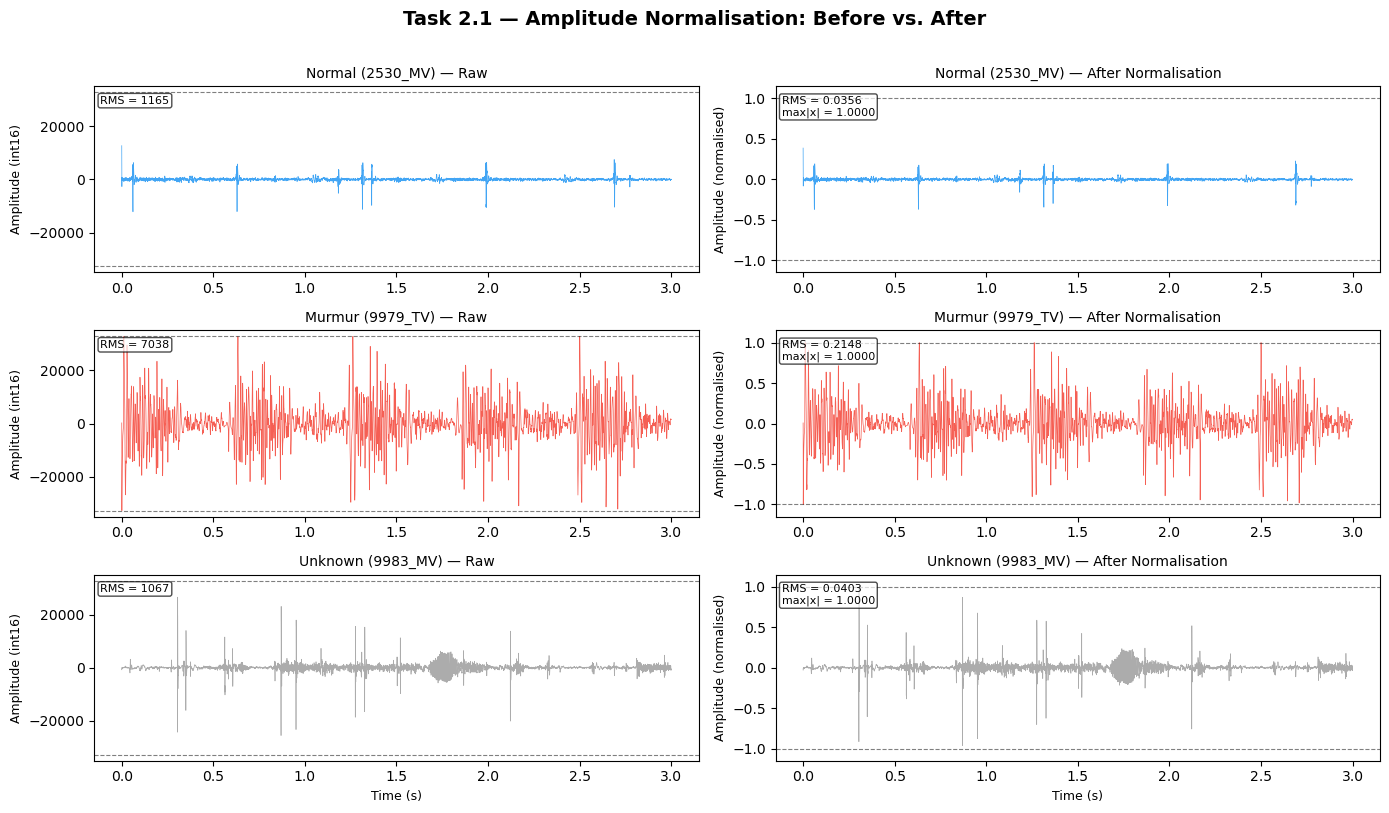

Saved: figures/preprocessing/s2_normalisation.png


In [30]:
SR = 4000
PLOT_SECS = 3.0      # show first 3 seconds for clarity
N_PLOT = int(PLOT_SECS * SR)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 8),
                          sharex=False, sharey=False)
fig.suptitle("Task 2.1 — Amplitude Normalisation: Before vs. After",
             fontsize=14, fontweight='bold', y=1.01)

COLOURS = {
    "Normal (2530_MV)":  "#2196F3",   # blue
    "Murmur (9979_TV)":  "#F44336",   # red
    "Unknown (9983_MV)": "#9E9E9E",   # grey
}

for row_idx, (label, (sr, raw)) in enumerate(raw_signals.items()):
    normed = norm_signals[label][1]
    colour = COLOURS[label]
    t = np.arange(N_PLOT) / SR

    # ── Left: raw int16 ───────────────────────────────────────────────────────
    ax_raw = axes[row_idx, 0]
    ax_raw.plot(t, raw[:N_PLOT], color=colour, linewidth=0.5, alpha=0.85)
    ax_raw.set_ylabel("Amplitude (int16)", fontsize=9)
    ax_raw.set_title(f"{label} — Raw", fontsize=10)
    ax_raw.axhline(32767,  color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_raw.axhline(-32768, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_raw.text(0.01, 0.95, f"RMS = {np.sqrt(np.mean(raw.astype(float)**2)):.0f}",
                transform=ax_raw.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    ax_raw.set_ylim(-35000, 35000)

    # ── Right: normalised float64 ─────────────────────────────────────────────
    ax_norm = axes[row_idx, 1]
    ax_norm.plot(t, normed[:N_PLOT], color=colour, linewidth=0.5, alpha=0.85)
    ax_norm.set_ylabel("Amplitude (normalised)", fontsize=9)
    ax_norm.set_title(f"{label} — After Normalisation", fontsize=10)
    ax_norm.axhline(1.0,  color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_norm.axhline(-1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_norm.text(0.01, 0.95,
                 f"RMS = {np.sqrt(np.mean(normed**2)):.4f}\nmax|x| = {np.max(np.abs(normed)):.4f}",
                 transform=ax_norm.transAxes, fontsize=8, va='top',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    ax_norm.set_ylim(-1.15, 1.15)

    # ── x-axis label only on bottom row ──────────────────────────────────────
    if row_idx == 2:
        ax_raw.set_xlabel("Time (s)", fontsize=9)
        ax_norm.set_xlabel("Time (s)", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/preprocessing/s2_normalisation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/preprocessing/s2_normalisation.png")

### Observations

**Before normalisation:**
- 9979_TV (Murmur) has RMS ≈ 7038, while 2530_MV (Normal) has RMS ≈ 1165 — a **6× difference**.
- All three examples hit the int16 clipping ceiling (±32768), indicated by the dashed lines.
  This means the raw amplitude maximum is an artifact of hardware saturation, not signal content.

**After normalisation:**
- All three recordings now occupy the same [-1, 1] range.
- RMS values are now comparable across examples.
- The **waveform shape is completely preserved** — normalisation is a linear scaling,
  no frequency content is altered.
- The relative amplitude differences *within* each recording are preserved 
  (murmur's filled systole is still visible relative to S1/S2).

**DAV note:** This step is classified as **Feature Normalisation** because it adjusts
the scale of existing features without creating new ones or changing dimensionality.
It is a precondition for the Feature Transformation step (spectrogram) that follows.

## Section 3: Feature Transformation — Log-Spectrogram

**DAV Category:** Feature Transformation  
**Input:** Normalised PCG waveform (float64, [-1, 1], 1D — shape (N,))  
**Algorithm:** Short-Time Fourier Transform (STFT) with Hann window → log-power  
**Output:** Log-power spectrogram (2D — shape (101 freq bins, T time frames))  

**Parameter choices (justified from paper + signal theory):**

| Parameter | Value | Reasoning |
|---|---|---|
| Window function | Hann | Smooth tapering reduces spectral leakage |
| Window length | 50 ms (200 samples) | ~half of S1/S2 duration (~100 ms) — balances time vs. frequency resolution |
| Hop length | 20 ms (80 samples) | Feature rate = 50 Hz, sufficient for tracking heart sound events |
| n_fft | 200 (= window length) | No zero-padding → frequency resolution = 4000/200 = 20 Hz |
| Log transform | log(power + 1e-10) | Compresses dynamic range; makes quiet murmur energy visible |

**Motivation (from Task 2.0, Observation 2):**  
Raw waveform encodes no frequency structure. Heart sounds have characteristic
spectral signatures (S1/S2 ~20–200 Hz, murmurs ~50–400 Hz) that are only
accessible after time-frequency decomposition.

In [21]:
from src.features.spectrogram import compute_log_spectrogram

SR = 4000

spectrograms = {}
for label, (sr, raw) in raw_signals.items():
    normed = norm_signals[label][1]
    S_log, freqs, times = compute_log_spectrogram(normed, sr=SR)
    spectrograms[label] = (S_log, freqs, times)

    duration = len(raw) / SR
    print(f"{label}")
    print(f"  Signal length : {len(raw)} samples = {duration:.2f}s")
    print(f"  Spectrogram   : {S_log.shape}  (freq_bins × time_frames)")
    print(f"  Freq axis     : {freqs[0]:.0f} – {freqs[-1]:.0f} Hz  "
          f"(resolution = {freqs[1]-freqs[0]:.0f} Hz, n_bins = {len(freqs)})")
    print(f"  Time axis     : {times[0]:.3f} – {times[-1]:.3f}s  "
          f"(feature rate = {1/(times[1]-times[0]):.0f} Hz)")
    print(f"  Value range   : min={S_log.min():.2f}, max={S_log.max():.2f}")
    print()

Normal (2530_MV)
  Signal length : 106752 samples = 26.69s
  Spectrogram   : (101, 1336)  (freq_bins × time_frames)
  Freq axis     : 0 – 2000 Hz  (resolution = 20 Hz, n_bins = 101)
  Time axis     : 0.000 – 26.700s  (feature rate = 50 Hz)
  Value range   : min=-23.03, max=-3.63

Murmur (9979_TV)
  Signal length : 91584 samples = 22.90s
  Spectrogram   : (101, 1146)  (freq_bins × time_frames)
  Freq axis     : 0 – 2000 Hz  (resolution = 20 Hz, n_bins = 101)
  Time axis     : 0.000 – 22.900s  (feature rate = 50 Hz)
  Value range   : min=-23.03, max=-2.12

Unknown (9983_MV)
  Signal length : 79808 samples = 19.95s
  Spectrogram   : (101, 999)  (freq_bins × time_frames)
  Freq axis     : 0 – 2000 Hz  (resolution = 20 Hz, n_bins = 101)
  Time axis     : 0.000 – 19.960s  (feature rate = 50 Hz)
  Value range   : min=-23.03, max=-4.76



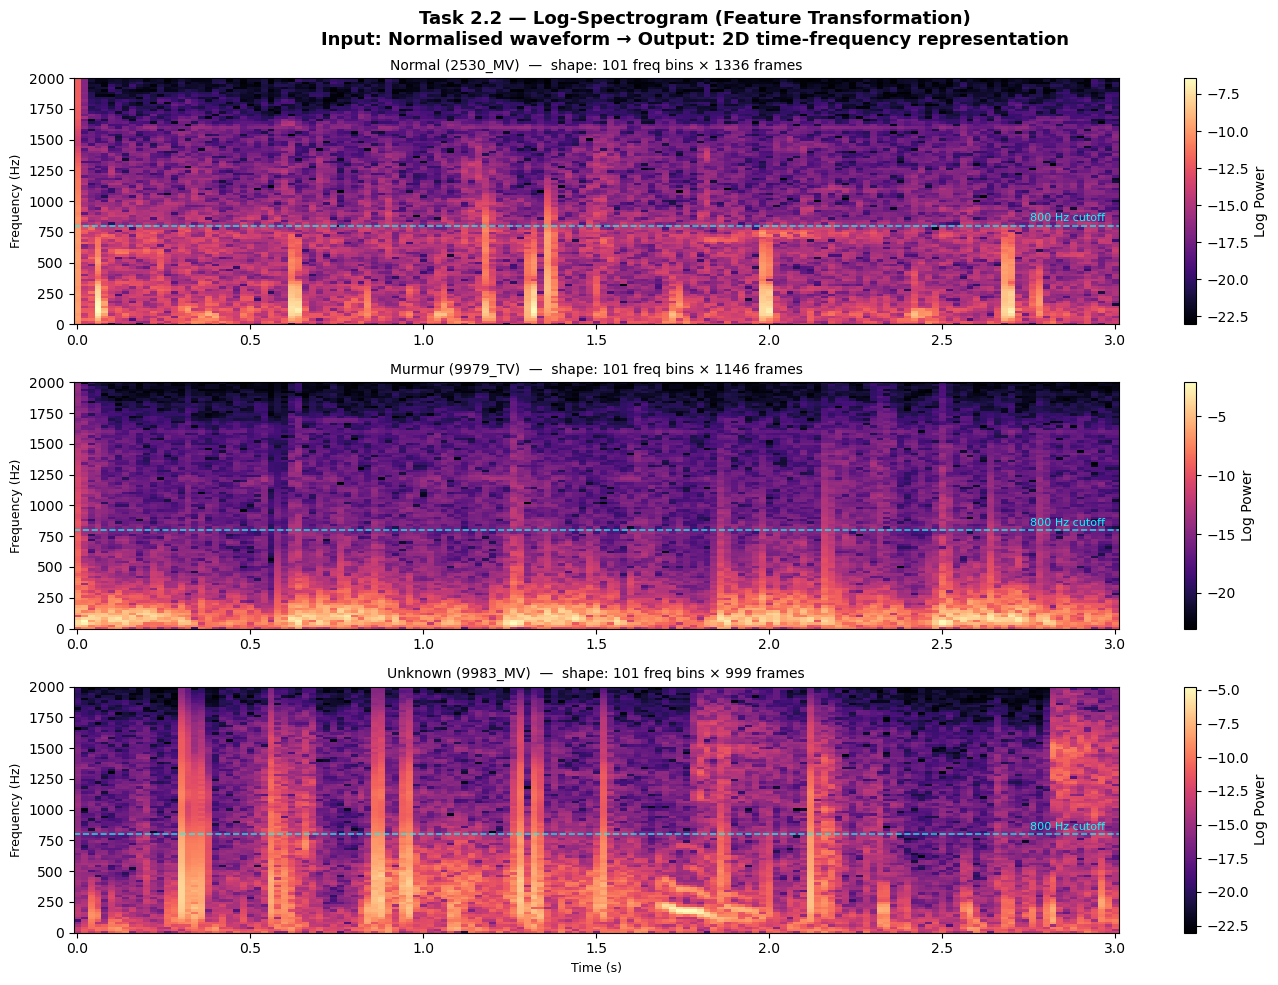

Saved: figures/preprocessing/s3_spectrogram_full.png


In [31]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Task 2.2 — Log-Spectrogram (Feature Transformation)\n"
             "Input: Normalised waveform → Output: 2D time-frequency representation",
             fontsize=13, fontweight='bold')

PLOT_SECS = 3.0

for idx, (label, (S_log, freqs, times)) in enumerate(spectrograms.items()):
    # Crop to first PLOT_SECS for display
    t_mask = times <= PLOT_SECS
    S_plot = S_log[:, t_mask]
    t_plot = times[t_mask]

    ax = axes[idx]
    im = ax.pcolormesh(t_plot, freqs, S_plot, shading='auto', cmap='magma')
    fig.colorbar(im, ax=ax, label='Log Power')

    # Mark 800 Hz cutoff
    ax.axhline(800, color='cyan', linewidth=1.2, linestyle='--', alpha=0.8)
    ax.text(t_plot[-1]*0.99, 820, '800 Hz cutoff', color='cyan',
            ha='right', va='bottom', fontsize=8)

    ax.set_ylabel("Frequency (Hz)", fontsize=9)
    ax.set_title(f"{label}  —  shape: {S_log.shape[0]} freq bins × {S_log.shape[1]} frames",
                 fontsize=10)
    ax.set_ylim(0, 2000)

    if idx == 2:
        ax.set_xlabel("Time (s)", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/preprocessing/s3_spectrogram_full.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/preprocessing/s3_spectrogram_full.png")

## Section 4: Feature Selection — Frequency Cropping (0–800 Hz)

**DAV Category:** Feature Selection  
**Input:** Full log-spectrogram (101 freq bins × T frames, range 0–2000 Hz)  
**Algorithm:** Boolean mask — retain bins where freq ≤ 800 Hz  
**Output:** Cropped spectrogram (41 freq bins × T frames, range 0–800 Hz)  

**Dimensionality reduction:** 101 → 41 bins = **59% of frequency features discarded**

**Motivation (from Task 2.0, Observation 3):**  
Heart sounds (S1, S2, murmurs) have energy concentrated below 800 Hz.
Frequencies above 800 Hz in PCG recordings are dominated by ambient noise,
speech artifacts, and stethoscope contact sounds — irrelevant to murmur detection
and potentially harmful (RNN may learn spurious correlates).

**This decision will be validated statistically in notebook 02b, Task 2.5c.**

In [24]:
import importlib
import src.features.spectrogram as spec_module
importlib.reload(spec_module)
from src.features.spectrogram import crop_frequency, compute_log_spectrogram

cropped_spectrograms = {}
for label, (S_log, freqs, times) in spectrograms.items():
    S_crop, freqs_crop = crop_frequency(S_log, freqs, max_freq=800)
    cropped_spectrograms[label] = (S_crop, freqs_crop, times)

    print(f"{label}")
    print(f"  Before crop : {S_log.shape}   freq range: {freqs[0]:.0f}–{freqs[-1]:.0f} Hz")
    print(f"  After crop  : {S_crop.shape}  freq range: {freqs_crop[0]:.0f}–{freqs_crop[-1]:.0f} Hz")
    print(f"  Bins removed: {S_log.shape[0] - S_crop.shape[0]}  "
          f"({(S_log.shape[0]-S_crop.shape[0])/S_log.shape[0]*100:.0f}% discarded)")
    print(f"  Verify freqs_crop[-1] == 800.0: {freqs_crop[-1] == 800.0}")
    print()

Normal (2530_MV)
  Before crop : (101, 1336)   freq range: 0–2000 Hz
  After crop  : (41, 1336)  freq range: 0–800 Hz
  Bins removed: 60  (59% discarded)
  Verify freqs_crop[-1] == 800.0: True

Murmur (9979_TV)
  Before crop : (101, 1146)   freq range: 0–2000 Hz
  After crop  : (41, 1146)  freq range: 0–800 Hz
  Bins removed: 60  (59% discarded)
  Verify freqs_crop[-1] == 800.0: True

Unknown (9983_MV)
  Before crop : (101, 999)   freq range: 0–2000 Hz
  After crop  : (41, 999)  freq range: 0–800 Hz
  Bins removed: 60  (59% discarded)
  Verify freqs_crop[-1] == 800.0: True



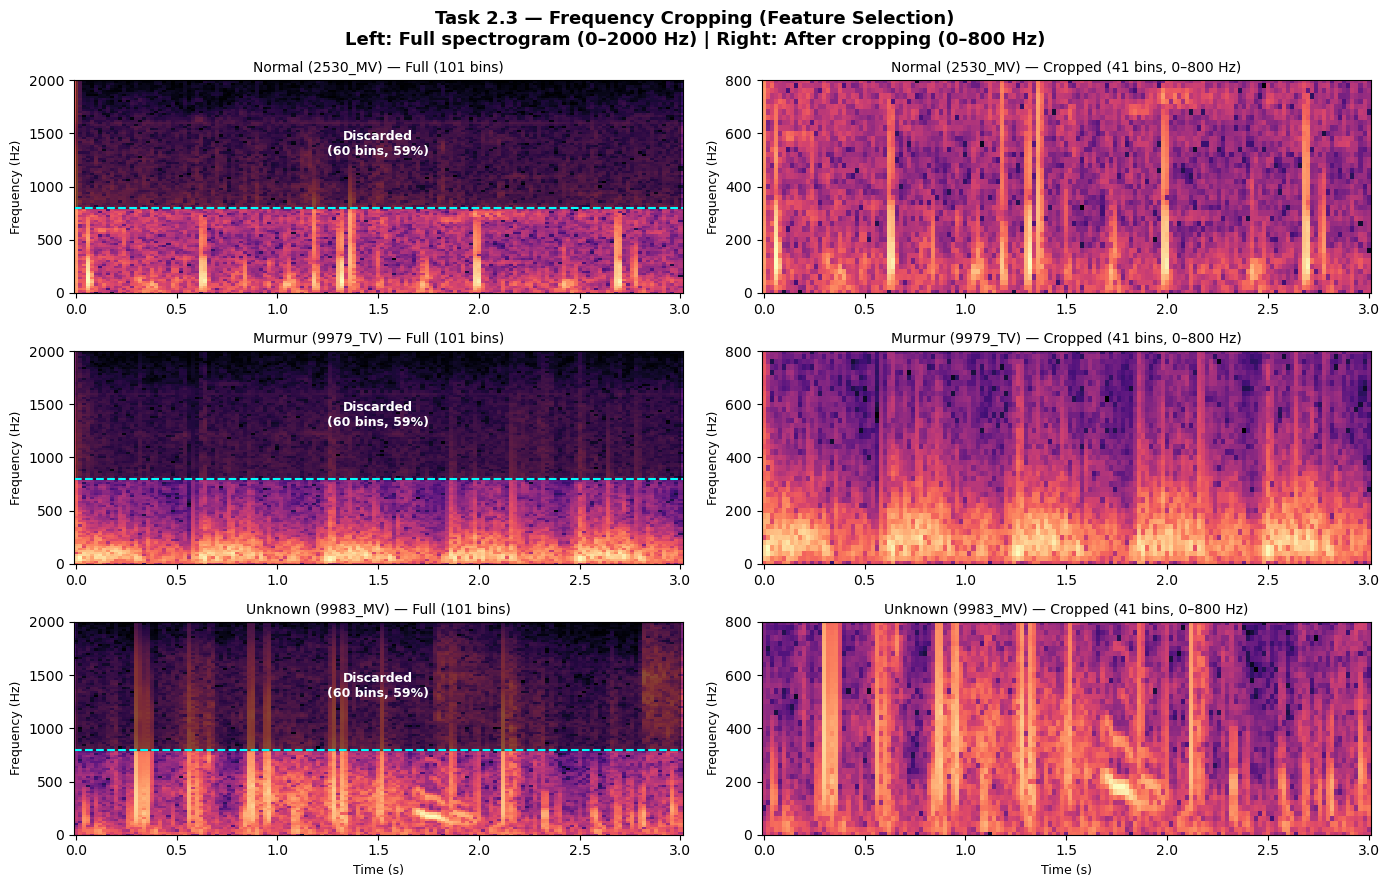

Saved: figures/preprocessing/s4_frequency_crop.png


In [32]:
PLOT_SECS = 3.0
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
fig.suptitle("Task 2.3 — Frequency Cropping (Feature Selection)\n"
             "Left: Full spectrogram (0–2000 Hz) | Right: After cropping (0–800 Hz)",
             fontsize=13, fontweight='bold')

for row_idx, label in enumerate(spectrograms.keys()):
    S_log, freqs, times   = spectrograms[label]
    S_crop, freqs_crop, _ = cropped_spectrograms[label]

    t_mask = times <= PLOT_SECS

    # ── Left: full spectrogram with cutoff line ───────────────────────────────
    ax_full = axes[row_idx, 0]
    ax_full.pcolormesh(times[t_mask], freqs, S_log[:, t_mask],
                       shading='auto', cmap='magma')
    ax_full.axhline(800, color='cyan', linewidth=1.5, linestyle='--')
    ax_full.fill_between([0, PLOT_SECS], 800, 2000,
                         color='black', alpha=0.45)
    ax_full.text(PLOT_SECS * 0.5, 1400,
                 'Discarded\n(60 bins, 59%)',
                 color='white', ha='center', va='center', fontsize=9,
                 fontweight='bold')
    ax_full.set_ylim(0, 2000)
    ax_full.set_ylabel("Frequency (Hz)", fontsize=9)
    ax_full.set_title(f"{label} — Full (101 bins)", fontsize=10)

    # ── Right: cropped spectrogram ────────────────────────────────────────────
    ax_crop = axes[row_idx, 1]
    ax_crop.pcolormesh(times[t_mask], freqs_crop, S_crop[:, t_mask],
                       shading='auto', cmap='magma')
    ax_crop.set_ylim(0, 800)
    ax_crop.set_ylabel("Frequency (Hz)", fontsize=9)
    ax_crop.set_title(f"{label} — Cropped (41 bins, 0–800 Hz)", fontsize=10)

    if row_idx == 2:
        ax_full.set_xlabel("Time (s)", fontsize=9)
        ax_crop.set_xlabel("Time (s)", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/preprocessing/s4_frequency_crop.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/preprocessing/s4_frequency_crop.png")

## Section 5: Feature Normalisation — Per-Row Z-Score

**DAV Category:** Feature Normalisation  
**Input:** Cropped log-spectrogram (41 freq bins × T frames, 0–800 Hz)  
**Algorithm:** For each frequency row f: subtract mean, divide by std across time axis  
**Output:** Normalised spectrogram (41 × T), each row has mean ≈ 0, std ≈ 1  

**Motivation (from Task 2.0, Observation 4):**  
S1 and S2 produce sharp, high-energy events that dominate the spectrogram.
Grade 1 murmurs (58% of Present cases) have diffuse, low-energy spectral content
~10–20 dB below S1/S2. Without equalisation, the RNN sees murmur-related frequency
bins as near-zero relative to S1/S2 — effectively invisible.
Per-row z-score ensures every frequency bin contributes equally to the RNN input.

In [27]:
import importlib
import src.features.spectrogram as spec_module
importlib.reload(spec_module)
from src.features.spectrogram import zscore_per_row

zscored_spectrograms = {}
for label, (S_crop, freqs_crop, times) in cropped_spectrograms.items():
    S_norm = zscore_per_row(S_crop)
    zscored_spectrograms[label] = (S_norm, freqs_crop, times)

    row_means = S_norm.mean(axis=1)
    row_stds  = S_norm.std(axis=1)
    print(f"{label}")
    print(f"  Shape             : {S_norm.shape}")
    print(f"  Row means — min: {row_means.min():.6f}, "
          f"max: {row_means.max():.6f}, mean: {row_means.mean():.6f}")
    print(f"  Row stds  — min: {row_stds.min():.4f}, "
          f"max: {row_stds.max():.4f}, mean: {row_stds.mean():.4f}")
    print()

Normal (2530_MV)
  Shape             : (41, 1336)
  Row means — min: -0.000000, max: 0.000000, mean: -0.000000
  Row stds  — min: 1.0000, max: 1.0000, mean: 1.0000

Murmur (9979_TV)
  Shape             : (41, 1146)
  Row means — min: -0.000000, max: 0.000000, mean: -0.000000
  Row stds  — min: 1.0000, max: 1.0000, mean: 1.0000

Unknown (9983_MV)
  Shape             : (41, 999)
  Row means — min: -0.000000, max: 0.000000, mean: -0.000000
  Row stds  — min: 1.0000, max: 1.0000, mean: 1.0000



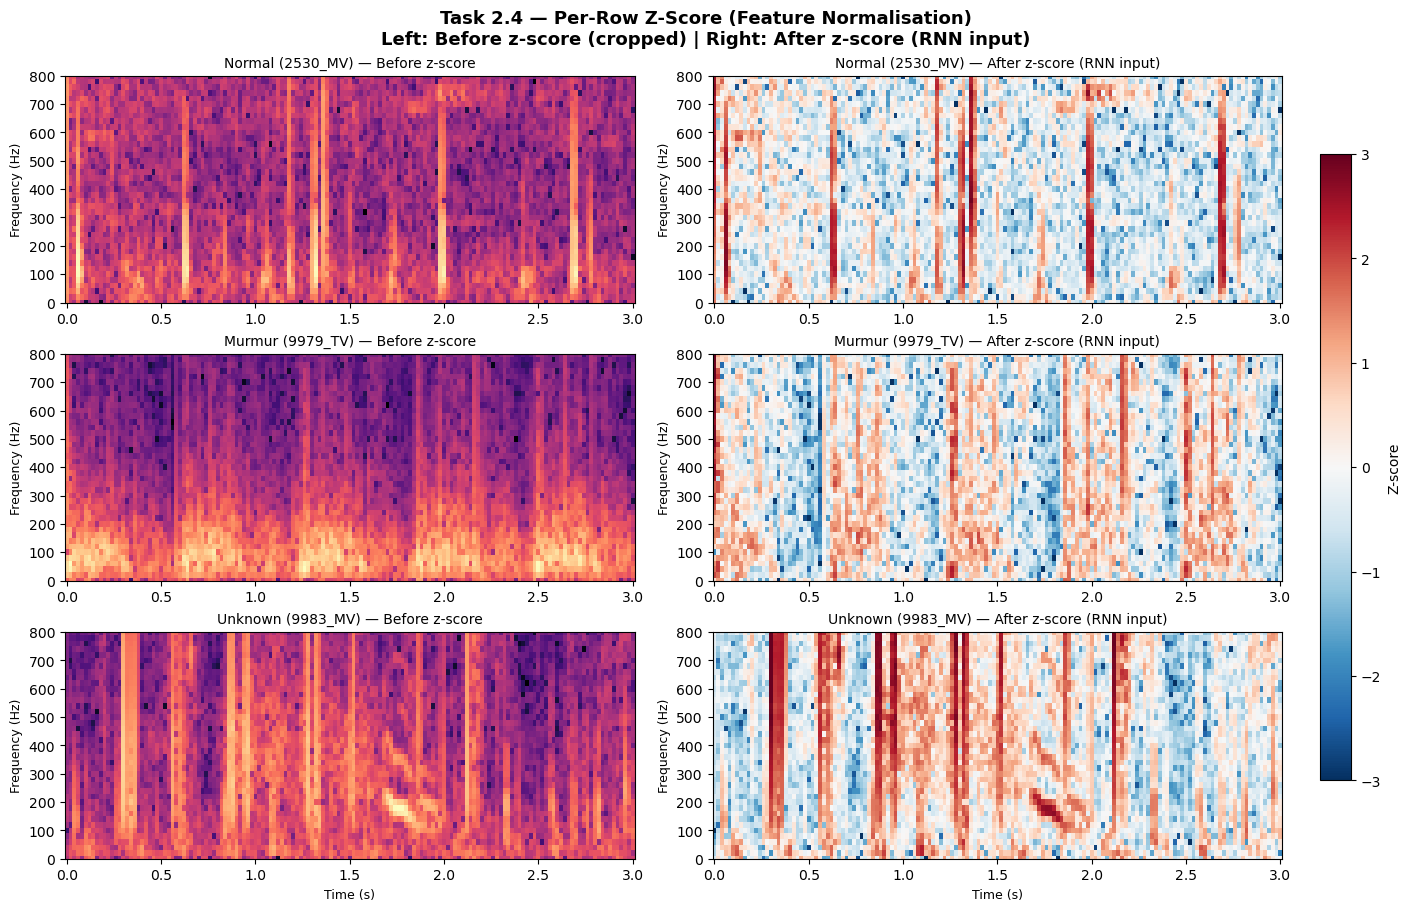

Saved: figures/preprocessing/s5_zscore_effect.png


In [33]:
PLOT_SECS = 3.0
fig, axes = plt.subplots(3, 2, figsize=(14, 9), constrained_layout=True)  # thay tight_layout
fig.suptitle("Task 2.4 — Per-Row Z-Score (Feature Normalisation)\n"
             "Left: Before z-score (cropped) | Right: After z-score (RNN input)",
             fontsize=13, fontweight='bold')

norm_cmap = plt.Normalize(vmin=-3, vmax=3)

for row_idx, label in enumerate(cropped_spectrograms.keys()):
    S_crop, freqs_crop, times = cropped_spectrograms[label]
    S_norm, _, _              = zscored_spectrograms[label]
    t_mask = times <= PLOT_SECS

    ax_before = axes[row_idx, 0]
    ax_before.pcolormesh(times[t_mask], freqs_crop, S_crop[:, t_mask],
                         shading='auto', cmap='magma')
    ax_before.set_ylabel("Frequency (Hz)", fontsize=9)
    ax_before.set_title(f"{label} — Before z-score", fontsize=10)
    ax_before.set_ylim(0, 800)

    ax_after = axes[row_idx, 1]
    im = ax_after.pcolormesh(times[t_mask], freqs_crop, S_norm[:, t_mask],
                              shading='auto', cmap='RdBu_r', norm=norm_cmap)
    ax_after.set_ylabel("Frequency (Hz)", fontsize=9)
    ax_after.set_title(f"{label} — After z-score (RNN input)", fontsize=10)
    ax_after.set_ylim(0, 800)

    if row_idx == 2:
        ax_before.set_xlabel("Time (s)", fontsize=9)
        ax_after.set_xlabel("Time (s)", fontsize=9)

fig.colorbar(im, ax=axes[:, 1], label='Z-score', shrink=0.8)

# KHÔNG dùng plt.tight_layout() — constrained_layout đã handle
plt.savefig("../figures/preprocessing/s5_zscore_effect.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/preprocessing/s5_zscore_effect.png")

## Section 6: Complete Pipeline Visualisation

Toàn bộ 4 bước preprocessing hiển thị tuần tự trên cùng một recording.
Mỗi panel = output của một bước, input của bước tiếp theo.

Pipeline: Raw PCG → Normalise → Log-Spectrogram → Crop 0–800Hz → Z-Score (RNN input)

Làm trên murmur example (9979_TV) trước — đây là example thú vị nhất vì murmur pattern visible sau z-score. Sau đó lặp lại cho Normal và Unknown.

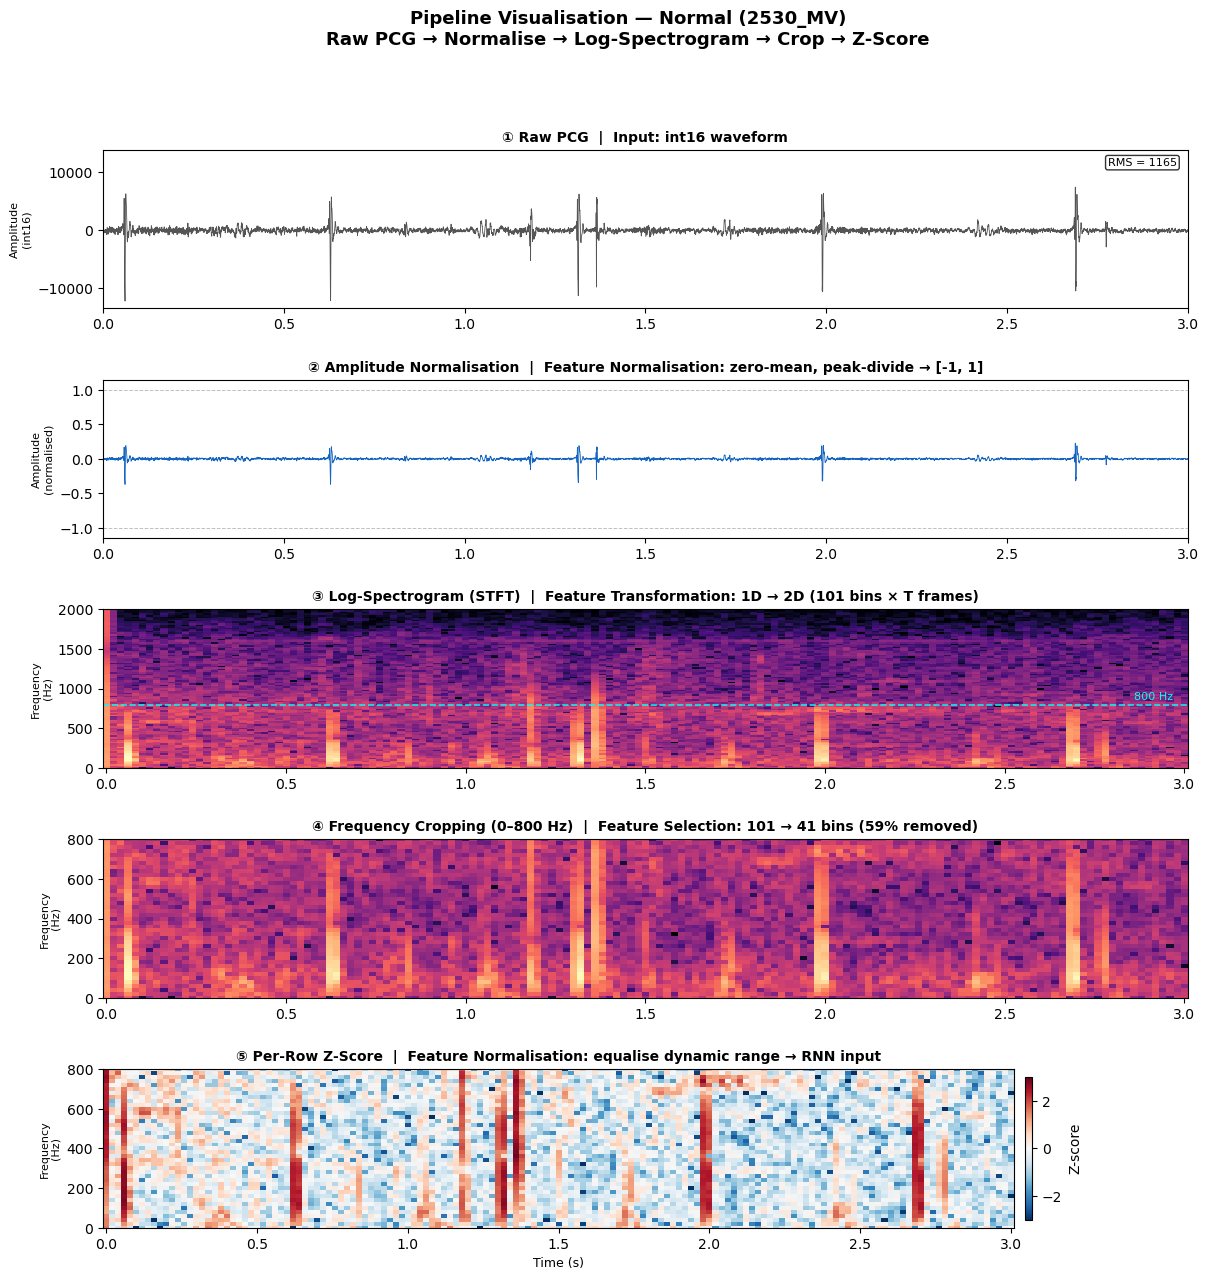

Saved: ../figures/preprocessing/s6_pipeline_normal.png


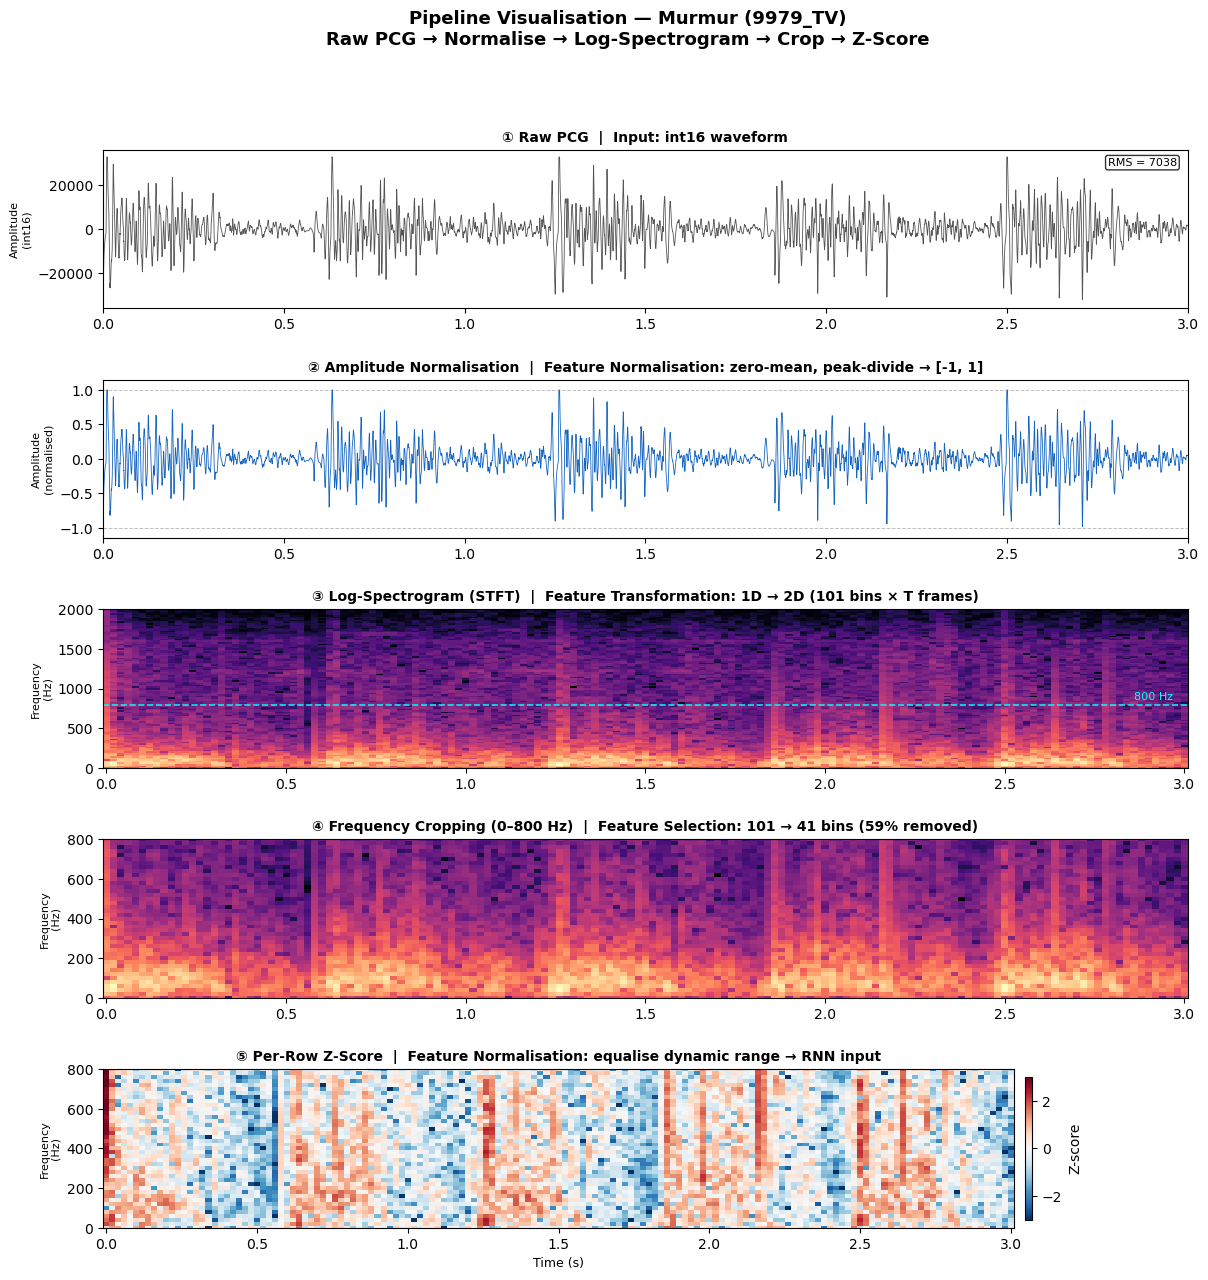

Saved: ../figures/preprocessing/s6_pipeline_murmur.png


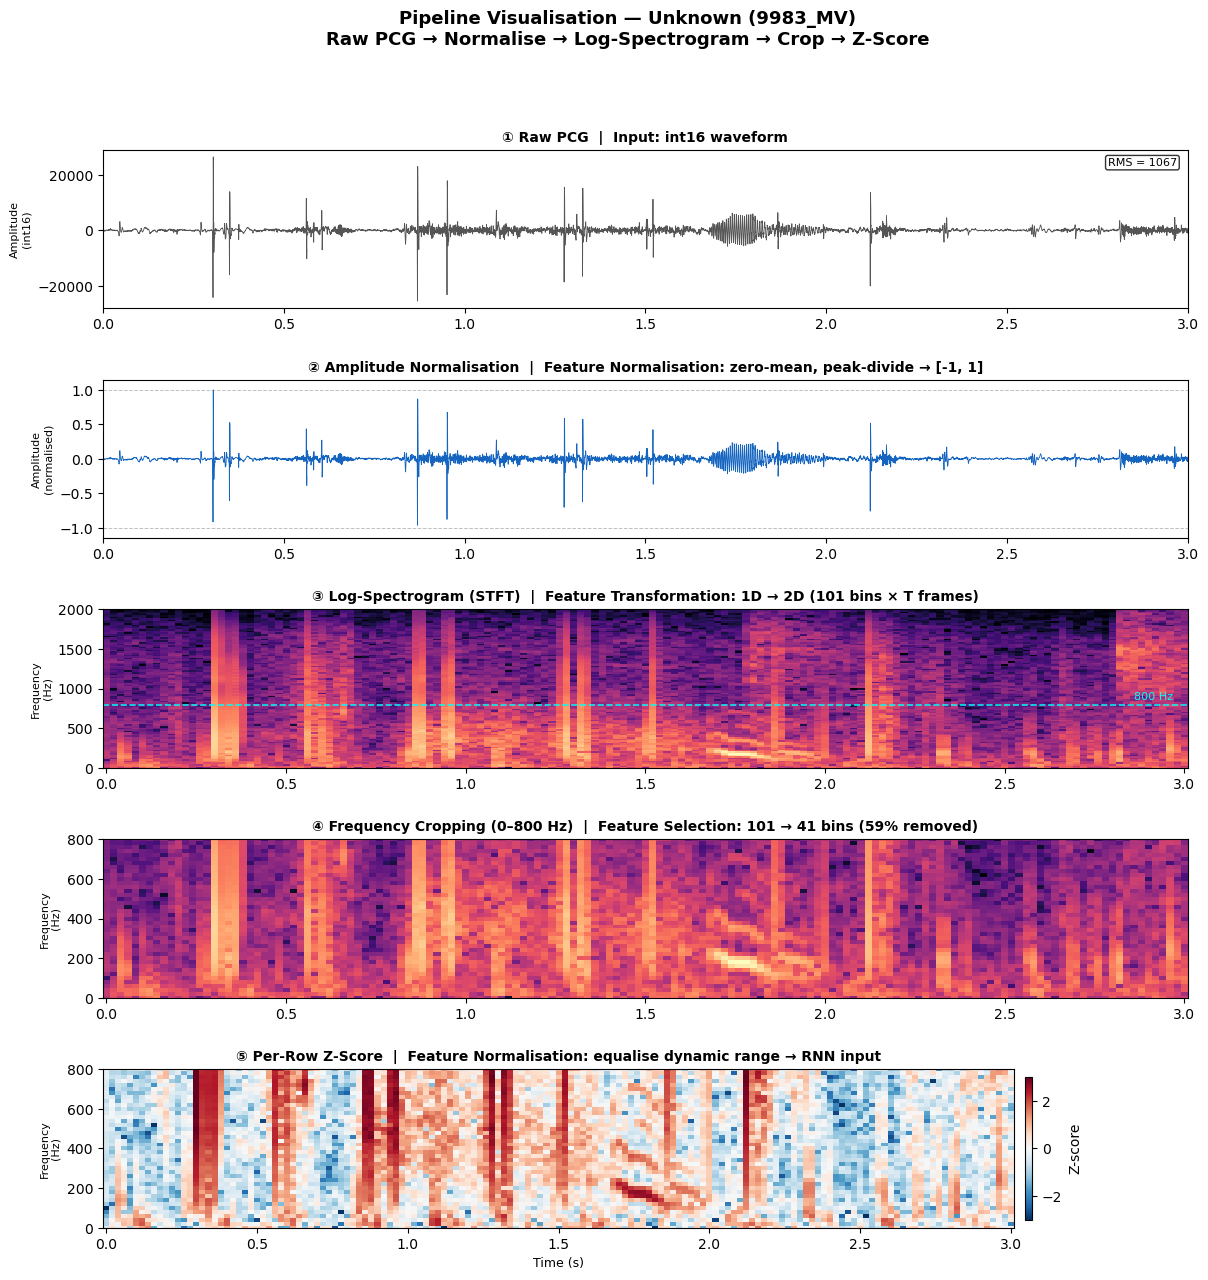

Saved: ../figures/preprocessing/s6_pipeline_unknown.png


In [34]:
PLOT_SECS = 3.0
SR = 4000

def plot_pipeline(label, raw_signal, norm_signal, S_log, freqs,
                  S_crop, freqs_crop, S_norm, times, save_path):

    t_full  = np.arange(int(PLOT_SECS * SR)) / SR
    t_mask  = times <= PLOT_SECS

    fig = plt.figure(figsize=(14, 14))
    gs  = fig.add_gridspec(5, 1, hspace=0.45)
    fig.suptitle(f"Pipeline Visualisation — {label}\n"
                 f"Raw PCG → Normalise → Log-Spectrogram → Crop → Z-Score",
                 fontsize=13, fontweight='bold')

    # ── Panel 1: Raw waveform ─────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(t_full, raw_signal[:len(t_full)], color='#555555', linewidth=0.6)
    ax1.set_title("① Raw PCG  |  Input: int16 waveform", fontsize=10, fontweight='bold')
    ax1.set_ylabel("Amplitude\n(int16)", fontsize=8)
    ax1.set_xlim(0, PLOT_SECS)
    rms = np.sqrt(np.mean(raw_signal.astype(float)**2))
    ax1.text(0.99, 0.95, f"RMS = {rms:.0f}", transform=ax1.transAxes,
             ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    # ── Panel 2: Normalised waveform ──────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(t_full, norm_signal[:len(t_full)], color='#1565C0', linewidth=0.6)
    ax2.set_title("② Amplitude Normalisation  |  Feature Normalisation: zero-mean, peak-divide → [-1, 1]",
                  fontsize=10, fontweight='bold')
    ax2.set_ylabel("Amplitude\n(normalised)", fontsize=8)
    ax2.set_xlim(0, PLOT_SECS)
    ax2.set_ylim(-1.15, 1.15)
    ax2.axhline(1,  color='grey', linewidth=0.7, linestyle='--', alpha=0.5)
    ax2.axhline(-1, color='grey', linewidth=0.7, linestyle='--', alpha=0.5)

    # ── Panel 3: Full log-spectrogram ─────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    ax3.pcolormesh(times[t_mask], freqs, S_log[:, t_mask],
                   shading='auto', cmap='magma')
    ax3.axhline(800, color='cyan', linewidth=1.2, linestyle='--', alpha=0.9)
    ax3.text(PLOT_SECS * 0.99, 830, '800 Hz', color='cyan',
             ha='right', va='bottom', fontsize=8)
    ax3.set_title("③ Log-Spectrogram (STFT)  |  Feature Transformation: 1D → 2D (101 bins × T frames)",
                  fontsize=10, fontweight='bold')
    ax3.set_ylabel("Frequency\n(Hz)", fontsize=8)
    ax3.set_ylim(0, 2000)

    # ── Panel 4: Cropped spectrogram ──────────────────────────────────────────
    ax4 = fig.add_subplot(gs[3])
    ax4.pcolormesh(times[t_mask], freqs_crop, S_crop[:, t_mask],
                   shading='auto', cmap='magma')
    ax4.set_title("④ Frequency Cropping (0–800 Hz)  |  Feature Selection: 101 → 41 bins (59% removed)",
                  fontsize=10, fontweight='bold')
    ax4.set_ylabel("Frequency\n(Hz)", fontsize=8)
    ax4.set_ylim(0, 800)

    # ── Panel 5: Z-scored spectrogram ─────────────────────────────────────────
    ax5 = fig.add_subplot(gs[4])
    im = ax5.pcolormesh(times[t_mask], freqs_crop, S_norm[:, t_mask],
                        shading='auto', cmap='RdBu_r',
                        vmin=-3, vmax=3)
    ax5.set_title("⑤ Per-Row Z-Score  |  Feature Normalisation: equalise dynamic range → RNN input",
                  fontsize=10, fontweight='bold')
    ax5.set_ylabel("Frequency\n(Hz)", fontsize=8)
    ax5.set_xlabel("Time (s)", fontsize=9)
    ax5.set_ylim(0, 800)
    fig.colorbar(im, ax=ax5, label='Z-score', pad=0.01, shrink=0.9)

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


# ── Run for all 3 examples ────────────────────────────────────────────────────
for label in raw_signals.keys():
    sr, raw   = raw_signals[label]
    _, normed = norm_signals[label]
    S_log, freqs, times         = spectrograms[label]
    S_crop, freqs_crop, _       = cropped_spectrograms[label]
    S_norm, _, _                = zscored_spectrograms[label]

    slug = label.split(" ")[0].lower()   # "normal", "murmur", "unknown"
    save_path = f"../figures/preprocessing/s6_pipeline_{slug}.png"

    plot_pipeline(label, raw, normed, S_log, freqs,
                  S_crop, freqs_crop, S_norm, times, save_path)

**Observations quan trọng của s6_pipeline_murmur.png**

**Panel ③ → ④:** Sau khi crop, vùng nhiễu cao tần biến mất, chỉ còn tín hiệu tim có ý nghĩa.

**Panel ④ → ⑤:** Đây là điểm quan trọng nhất — nhìn panel ⑤, thấy rõ các khối đỏ xen kẽ đều đặn giữa các cột S1/S2. Đó chính là holosystolic murmur đã được z-score "kéo lên" thành visible. Nếu không có z-score, murmur energy bị S1/S2 át hoàn toàn ở panel ④.

## Section 7: Spectrogram Comparison by Class

**Input:** Fully preprocessed spectrograms (41 × T, z-scored) — đây là thứ RNN thực sự nhìn thấy  
**Purpose:** Visualise class-discriminative patterns trước khi train model

Mục tiêu: 3 spectrograms sau full preprocessing (z-scored) side-by-side, cho thấy visual differences mà RNN phải học để phân biệt 3 classes.

Câu hỏi: Nhìn bằng mắt, 3 classes có phân biệt được không?

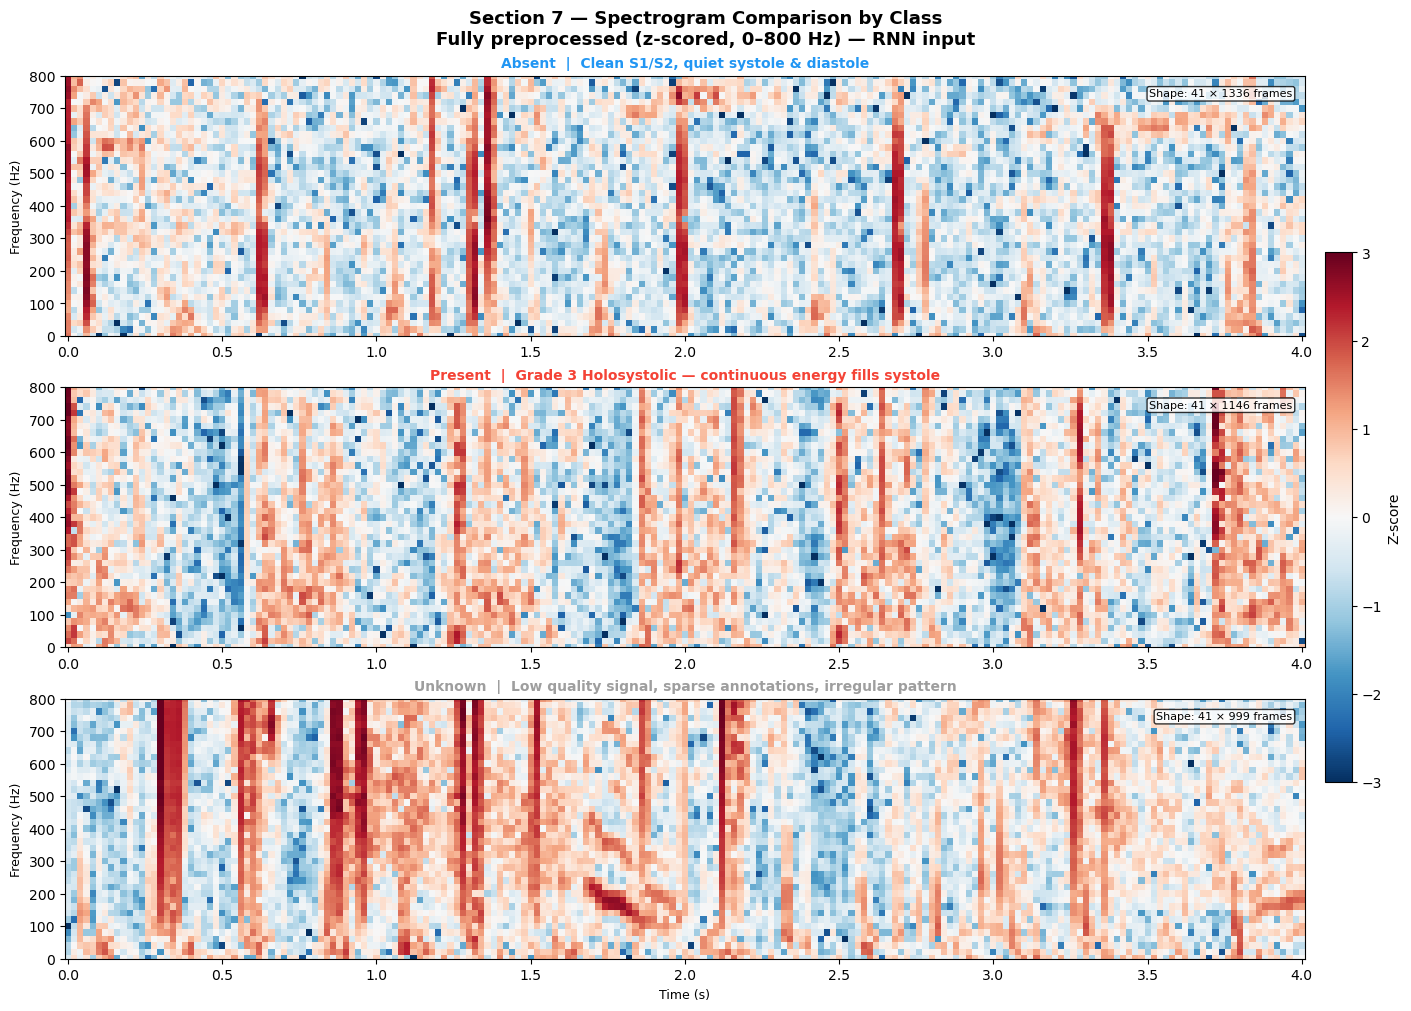

Saved: figures/preprocessing/s7_spectrogram_comparison.png


In [37]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True)
fig.suptitle("Section 7 — Spectrogram Comparison by Class\n"
             "Fully preprocessed (z-scored, 0–800 Hz) — RNN input",
             fontsize=13, fontweight='bold')

PLOT_SECS = 4.0

CLASS_COLOURS = {
    "Normal (2530_MV)":  "#2196F3",
    "Murmur (9979_TV)":  "#F44336",
    "Unknown (9983_MV)": "#9E9E9E",
}

CLASS_INFO = {
    "Normal (2530_MV)":  "Absent  |  Clean S1/S2, quiet systole & diastole",
    "Murmur (9979_TV)":  "Present  |  Grade 3 Holosystolic — continuous energy fills systole",
    "Unknown (9983_MV)": "Unknown  |  Low quality signal, sparse annotations, irregular pattern",
}

norm_cmap = plt.Normalize(vmin=-3, vmax=3)

for idx, label in enumerate(zscored_spectrograms.keys()):
    S_norm, freqs_crop, times = zscored_spectrograms[label]
    t_mask = times <= PLOT_SECS

    ax = axes[idx]
    im = ax.pcolormesh(times[t_mask], freqs_crop, S_norm[:, t_mask],
                       shading='auto', cmap='RdBu_r', norm=norm_cmap)

    ax.set_ylabel("Frequency (Hz)", fontsize=9)
    ax.set_ylim(0, 800)
    ax.set_title(f"{CLASS_INFO[label]}", fontsize=10, fontweight='bold',
                 color=CLASS_COLOURS[label])

    # Annotate shape
    ax.text(0.99, 0.95, f"Shape: {S_norm.shape[0]} × {S_norm.shape[1]} frames",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    if idx == 2:
        ax.set_xlabel("Time (s)", fontsize=9)

fig.colorbar(im, ax=axes, label='Z-score', shrink=0.6, pad=0.01)

plt.savefig("../figures/preprocessing/s7_spectrogram_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/preprocessing/s7_spectrogram_comparison.png")

**Nhận xét:**

**Normal (2530_MV):** Cột đỏ hẹp, sắc nét, lặp đều đặn — đó là S1/S2. Khoảng giữa (systole/diastole) xanh nhạt, yên tĩnh. Pattern rất rhythmic, dễ nhận ra.

**Murmur (9979_TV):** Khác biệt rõ nhất — khoảng giữa S1/S2 không xanh mà là vùng đỏ/trắng lan rộng liên tục, đặc biệt ở dải 0–400 Hz. Đây là holosystolic murmur energy. RNN cần học phân biệt "systole yên tĩnh" vs "systole có energy" này.

**Unknown (9983_MV):** Không có cấu trúc S1/systole/S2/diastole rõ ràng — vùng đỏ xuất hiện bất quy tắc, rải rác toàn bộ time axis. Một số spike rất cao ở ~100 Hz (horizontal band đỏ ~t=1.5s) — noise artifact điển hình.

## Section 8: Frequency Content by Class

**Input:** Log-spectrograms trước z-score (để giữ nguyên scale energy tuyệt đối)  
**Method:** Với mỗi recording, tính mean energy theo time axis cho từng frequency bin.
            Sau đó average theo class.  
**Purpose:** Xác định visually dải tần nào discriminative giữa Present và Absent.
             Đây là phiên bản visual của Task 2.5c (statistical version trong notebook 02b).
Mục tiêu: Average power spectrum theo class — line plot đơn giản cho thấy murmur energy tập trung ở dải tần nào so với Normal.

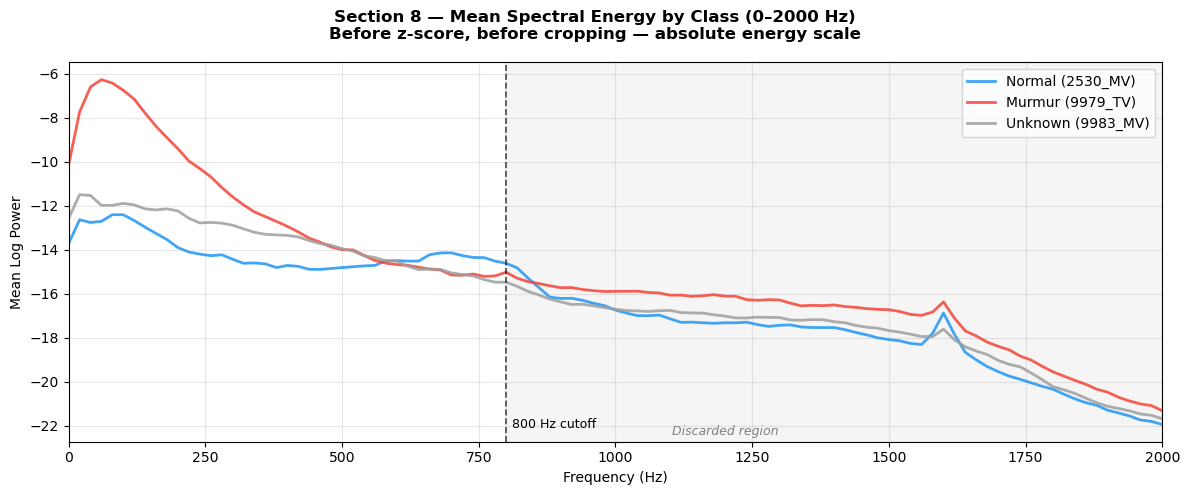

Saved: figures/preprocessing/s8_frequency_content.png


In [38]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Section 8 — Mean Spectral Energy by Class (0–2000 Hz)\n"
             "Before z-score, before cropping — absolute energy scale",
             fontsize=12, fontweight='bold')

COLOURS_CLASS = {
    "Normal (2530_MV)":  "#2196F3",
    "Murmur (9979_TV)":  "#F44336",
    "Unknown (9983_MV)": "#9E9E9E",
}

for label, (S_log, freqs, times) in spectrograms.items():
    # Mean energy per frequency bin across time (per recording)
    mean_energy = S_log.mean(axis=1)   # shape (101,)
    ax.plot(freqs, mean_energy,
            color=COLOURS_CLASS[label],
            linewidth=2.0,
            label=label,
            alpha=0.85)

# Mark 800 Hz cutoff
ax.axvline(800, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(810, ax.get_ylim()[0] + 0.5, '800 Hz cutoff',
        fontsize=9, va='bottom', ha='left', color='black')

# Shade discarded region
ax.axvspan(800, 2000, alpha=0.08, color='grey')
ax.text(1200, ax.get_ylim()[0] + 0.3, 'Discarded region',
        fontsize=9, ha='center', color='grey', style='italic')

ax.set_xlabel("Frequency (Hz)", fontsize=10)
ax.set_ylabel("Mean Log Power", fontsize=10)
ax.set_xlim(0, 2000)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/preprocessing/s8_frequency_content.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/preprocessing/s8_frequency_content.png")

**Key Observations**

**1. Murmur energy cao hơn Normal ở 0–800 Hz (gap lớn nhất ~80 Hz, ~6 dB)**  
Vì murmur là âm thanh liên tục trong systole — nó cộng thêm energy vào
toàn bộ low-to-mid frequency range, không chỉ một dải hẹp.

**2. Ba lines converge sau 800 Hz → không còn class discrimination**  
Vùng trên 800 Hz là hardware noise và ambient sound — không liên quan
đến cardiac physiology nên energy giống nhau ở cả 3 classes.
Đây là visual justification trực tiếp cho quyết định crop tại 800 Hz.

**3. Unknown nằm giữa, không thấp nhất ở 0–200 Hz**  
Vì 9983_MV có noise burst bất thường ở low frequencies (thấy rõ
trong Section 7) — energy cao nhưng không có cấu trúc cardiac.

**4. Spike ~1600 Hz ở cả 3 examples**  
Resonance artifact của thiết bị Littmann 3200, không phải cardiac signal
→ thêm lý do để loại bỏ high-frequency content.

## Section 9: Parameter Summary & DAV Justification

### 9.1 Feature Extraction Parameters

| Parameter | Value | Unit | Source | Justification |
|---|---|---|---|---|
| Sampling rate | 4000 | Hz | Fixed (Littmann 3200) | Hardware constraint — not a design choice |
| Window function | Hann | — | McDonald et al. | Smooth tapering, reduces spectral leakage |
| Window length | 50 | ms (200 samples) | McDonald et al. | ~half of S1/S2 duration (~100 ms); balances time vs. frequency resolution |
| Hop length | 20 | ms (80 samples) | McDonald et al. | Feature rate = 50 Hz; sufficient for heart sound event tracking |
| n_fft | 200 | samples | = win_length | No zero-padding → frequency resolution = sr/n_fft = 20 Hz |
| Frequency resolution | 20 | Hz | Derived | 4000 / 200 = 20 Hz per bin |
| Feature rate | 50 | Hz | Derived | 1 / 0.020 = 50 frames/second |
| Frequency range | 0–800 | Hz | McDonald et al. + Section 8 | Validated: discriminative content below 800 Hz (Section 8); full statistical confirmation in notebook 02b Task 2.5c |
| Frequency bins (after crop) | 41 | bins | Derived | (800/20) + 1 = 41 bins |
| Row normalisation | Per-row z-score | — | McDonald et al. | Equalises dynamic range; makes Grade 1 murmur energy visible |

### 9.2 DAV Terminology Mapping

| Step | DAV Category | Input Shape | Output Shape | Dimensionality Effect |
|---|---|---|---|---|
| Amplitude normalisation | Feature Normalisation | (N,) int16 | (N,) float64 | None — scale only |
| Log-spectrogram (STFT) | **Feature Transformation** | (N,) float64 | (101, T) float64 | 1D → 2D: exposes time-frequency structure |
| Frequency cropping | **Feature Selection** | (101, T) | (41, T) | −59% frequency features (60 bins removed) |
| Per-row z-score | Feature Normalisation | (41, T) | (41, T) | None — equalises dynamic range per row |

### 9.3 Design Decisions Not Taken (and Why)

| Alternative | Reason Not Used |
|---|---|
| MFCC (Mel-frequency cepstral coefficients) | Loses temporal fine-structure; less interpretable than spectrogram |
| Mel-scale spectrogram | Non-linear frequency axis harder to justify for cardiac acoustics; linear scale maps directly to Hz |
| Wavelet transform | More complex; no clear advantage for this frequency range |
| Zero-padding (n_fft > win_length) | Increases frequency resolution artificially without new information |
| Global z-score (across all rows together) | Would not equalise murmur vs. S1/S2 — need per-row to equalise each frequency band independently |

### 9.4 Summary: What the RNN Receives

Each recording is transformed from:
- **Input:** Raw int16 waveform, N samples (e.g. 86,000 for a 21.5s recording)
- **Output:** 41 × T normalised spectrogram (e.g. 41 × 1073 for same recording)
- Each column = one 20ms time frame
- Each row = one frequency band (0 Hz, 20 Hz, ..., 800 Hz), z-score normalised
- Values represent relative spectral energy — positive = above mean for that frequency band

## Section 10: Reusable Feature Extraction Module

Đóng gói toàn bộ pipeline vào `src/features/spectrogram.py::extract_features()`.
Verify trên 3 cross-phase examples, sau đó test batch processing.

In [41]:
import importlib
import src.features.spectrogram as spec_module
importlib.reload(spec_module)
from src.features.spectrogram import extract_features

DATA_ROOT = Path("../data/raw/training_data")

print("=== Single-file extraction test ===\n")
for label, filename in EXAMPLES.items():
    features, freqs, times = extract_features(DATA_ROOT / filename)
    print(f"{label}")
    print(f"  Output shape : {features.shape}")
    print(f"  Freq range   : {freqs[0]:.0f}–{freqs[-1]:.0f} Hz")
    print(f"  Row means    : min={features.mean(axis=1).min():.6f}, "
          f"max={features.mean(axis=1).max():.6f}")
    print(f"  Row stds     : min={features.std(axis=1).min():.4f}, "
          f"max={features.std(axis=1).max():.4f}")
    print()

=== Single-file extraction test ===

Normal (2530_MV)
  Output shape : (41, 1336)
  Freq range   : 0–800 Hz
  Row means    : min=-0.000000, max=0.000000
  Row stds     : min=1.0000, max=1.0000

Murmur (9979_TV)
  Output shape : (41, 1146)
  Freq range   : 0–800 Hz
  Row means    : min=-0.000000, max=0.000000
  Row stds     : min=1.0000, max=1.0000

Unknown (9983_MV)
  Output shape : (41, 999)
  Freq range   : 0–800 Hz
  Row means    : min=-0.000000, max=0.000000
  Row stds     : min=1.0000, max=1.0000



In [45]:
from src.features.spectrogram import extract_features_batch
from pathlib import Path
import pandas as pd

recordings = pd.read_csv("../data/metadata/recordings.csv")

DATA_ROOT = Path("../data/raw/training_data")

# Lấy filename từ wav_path rồi prepend DATA_ROOT
sample_paths = [DATA_ROOT / Path(p).name
                for p in recordings['wav_path'].head(10)]

# Verify
for p in sample_paths[:3]:
    print(f"{p.name}: {'EXISTS' if p.exists() else 'MISSING'}")

print()
print("=== Batch extraction test (10 files) ===\n")
results = extract_features_batch(sample_paths, show_progress=True)

success = [r for r in results if r is not None]
print(f"\nSuccess: {len(success)}/10")
print(f"Shapes: {[r[0].shape for r in success]}")

2530_AV.wav: EXISTS
2530_PV.wav: EXISTS
2530_TV.wav: EXISTS

=== Batch extraction test (10 files) ===

  [0/10] Processing 2530_AV.wav...

Success: 10/10
Shapes: [(41, 1181), (41, 654), (41, 751), (41, 1336), (41, 909), (41, 1014), (41, 1146), (41, 1059), (41, 1154), (41, 1334)]


## Giải thích output `(41, T)`
```
(41, 1181)  ←  41 frequency bins × 1181 time frames
(41,  654)  ←  41 frequency bins ×  654 time frames
...
```
* **41** = số **frequency bins** sau khi crop (`0 Hz`, `20 Hz`, `40 Hz`, ..., `800 Hz`). Giá trị này **cố định** cho mọi recording.
* **T** = số **time frames**, thay đổi tùy theo độ dài recording. Mỗi frame tương ứng **20 ms**, nên:

  * `T = 1181` → recording dài `1181 × 20 ms = 23.6 s`
  * `T = 654` → recording dài `654 × 20 ms = 13.1 s`

## Cách RNN nhận input này
RNN đọc spectrogram **theo từng cột**. Ở mỗi bước thời gian `t`, mô hình nhận vào một **vector 41 chiều** (41 frequency bins tại thời điểm đó), sau đó dự đoán xác suất thuộc một trong **5 states**:

```
{S1, Systole, S2, Diastole, Murmur}
```

```
Time:      t=1        t=2        t=3    ...   t=T
Input:   [41 bins]  [41 bins]  [41 bins] ... [41 bins]
Output:  [5 probs]  [5 probs]  [5 probs] ... [5 probs]
```

`T` khác nhau **không phải là vấn đề**, vì RNN được thiết kế để xử lý các **sequence có độ dài bất kỳ**. Đây cũng là một trong những lý do sử dụng **RNN** thay vì **CNN** hoặc **fully-connected network**.

Việc xử lý nhiều recordings có độ dài khác nhau trong cùng một batch (ví dụ bằng **padding** hoặc **packed sequences**) chỉ phát sinh ở **Phase 3**; chưa cần quan tâm ở giai đoạn hiện tại.


## Section 11: Pipeline Framework Diagram

Full pipeline từ Raw PCG đến murmur classification,
với input/output shapes annotated tại mỗi stage.
Đây là Figure 1 trong report.

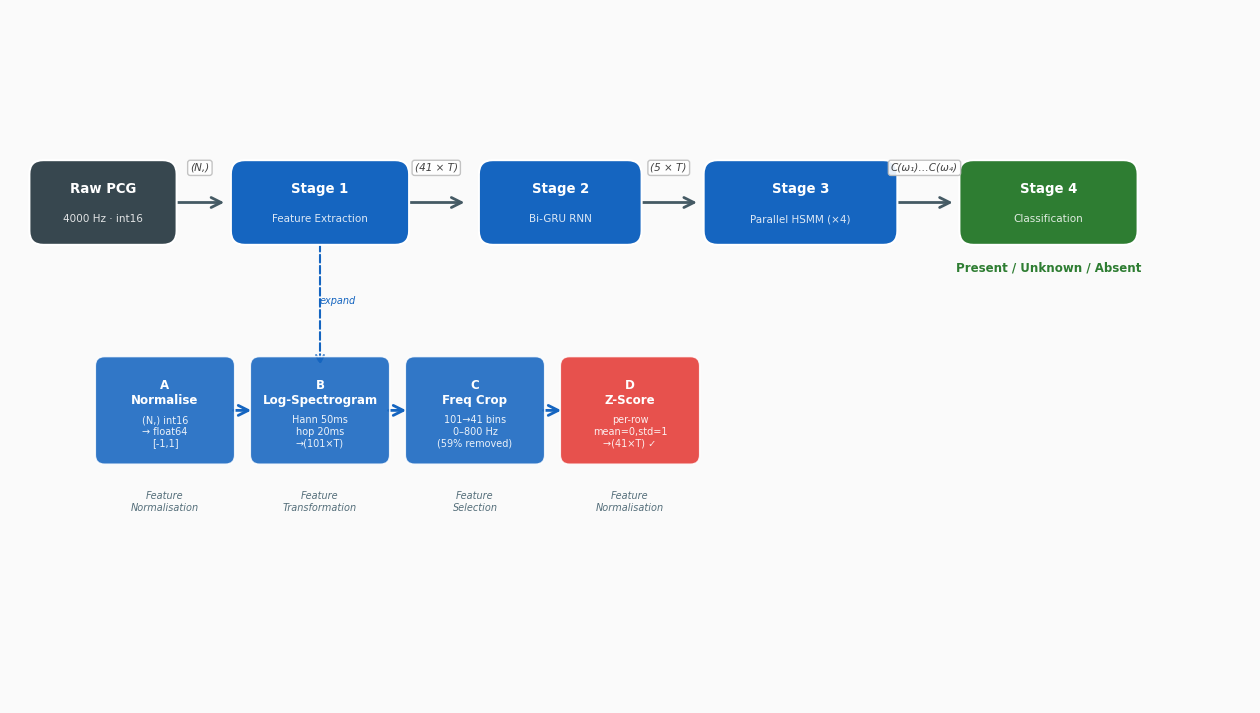

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

# ── Colour palette ────────────────────────────────────────────────────────────
C_STAGE   = '#1565C0'    # main stage boxes
C_SUB     = '#E3F2FD'    # sub-step boxes
C_IO      = '#F5F5F5'    # I/O annotation boxes
C_ARROW   = '#455A64'
C_TEXT    = 'white'
C_SUBTEXT = '#1A237E'
C_ACCENT  = '#E53935'    # highlight RNN input

def draw_box(ax, x, y, w, h, label, sublabel=None,
             fc='#1565C0', tc='white', fontsize=10, radius=0.18):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle=f"round,pad=0.05,rounding_size={radius}",
                          facecolor=fc, edgecolor='white', linewidth=1.5,
                          zorder=3)
    ax.add_patch(box)
    if sublabel:
        ax.text(x, y + 0.18, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=tc, zorder=4)
        ax.text(x, y - 0.22, sublabel, ha='center', va='center',
                fontsize=7.5, color=tc, alpha=0.85, zorder=4)
    else:
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=tc, zorder=4)

def draw_arrow(ax, x1, x2, y, color='#455A64'):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=2.0, mutation_scale=18),
                zorder=2)

def draw_io_label(ax, x, y, text, color='#424242', fontsize=7.5):
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=color, style='italic',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor='#BDBDBD', alpha=0.9),
            zorder=5)

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 1 — Main pipeline stages (y=6.8)
# ═══════════════════════════════════════════════════════════════════════════════
Y_MAIN = 6.5

# Stage 0: Raw PCG
draw_box(ax, 1.2, Y_MAIN, 1.8, 1.0,
         'Raw PCG', '4000 Hz · int16',
         fc='#37474F', fontsize=9.5)

draw_arrow(ax, 2.1, 2.8, Y_MAIN)
draw_io_label(ax, 2.45, Y_MAIN + 0.45, '(N,)')

# Stage 1: Feature Extraction
draw_box(ax, 4.0, Y_MAIN, 2.2, 1.0,
         'Stage 1', 'Feature Extraction',
         fc=C_STAGE, fontsize=9.5)

draw_arrow(ax, 5.1, 5.9, Y_MAIN)
draw_io_label(ax, 5.5, Y_MAIN + 0.45, '(41 × T)')

# Stage 2: RNN
draw_box(ax, 7.1, Y_MAIN, 2.0, 1.0,
         'Stage 2', 'Bi-GRU RNN',
         fc=C_STAGE, fontsize=9.5)

draw_arrow(ax, 8.1, 8.9, Y_MAIN)
draw_io_label(ax, 8.5, Y_MAIN + 0.45, '(5 × T)')

# Stage 3: Parallel HSMM
draw_box(ax, 10.2, Y_MAIN, 2.4, 1.0,
         'Stage 3', 'Parallel HSMM (×4)',
         fc=C_STAGE, fontsize=9.5)

draw_arrow(ax, 11.4, 12.2, Y_MAIN)
draw_io_label(ax, 11.8, Y_MAIN + 0.45, 'C(ω₁)…C(ω₄)')

# Stage 4: Classification
draw_box(ax, 13.4, Y_MAIN, 2.2, 1.0,
         'Stage 4', 'Classification',
         fc='#2E7D32', fontsize=9.5)

# Output label
ax.text(13.4, Y_MAIN - 0.85, 'Present / Unknown / Absent',
        ha='center', va='center', fontsize=8.5,
        color='#2E7D32', fontweight='bold')

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 2 — Stage 1 expansion (y=4.0)
# ═══════════════════════════════════════════════════════════════════════════════
Y_SUB = 3.8
Y_CONN = Y_MAIN - 0.5   # connector from Stage 1 box to sub-steps

# Vertical connector from Stage 1 down
ax.annotate('', xy=(4.0, Y_SUB + 0.55), xytext=(4.0, Y_MAIN - 0.5),
            arrowprops=dict(arrowstyle='->', color=C_STAGE,
                            lw=1.5, linestyle='dashed', mutation_scale=14),
            zorder=2)
ax.text(4.0, (Y_MAIN - 0.5 + Y_SUB + 0.55) / 2 + 0.05,
        'expand', ha='left', va='center', fontsize=7,
        color=C_STAGE, style='italic')

# Sub-step boxes
SUB_STEPS = [
    (2.0,  'A\nNormalise',       '(N,) int16\n→ float64\n[-1,1]'),
    (4.0,  'B\nLog-Spectrogram', 'Hann 50ms\nhop 20ms\n→(101×T)'),
    (6.0,  'C\nFreq Crop',       '101→41 bins\n0–800 Hz\n(59% removed)'),
    (8.0,  'D\nZ-Score',         'per-row\nmean=0,std=1\n→(41×T) ✓'),
]

for x_sub, title, detail in SUB_STEPS:
    # Sub box
    fc_sub = C_ACCENT if '✓' in detail else C_STAGE
    box = FancyBboxPatch((x_sub - 0.85, Y_SUB - 0.65), 1.7, 1.3,
                          boxstyle='round,pad=0.05,rounding_size=0.12',
                          facecolor=fc_sub, edgecolor='white',
                          linewidth=1.2, alpha=0.88, zorder=3)
    ax.add_patch(box)
    ax.text(x_sub, Y_SUB + 0.22, title, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=4)
    ax.text(x_sub, Y_SUB - 0.28, detail, ha='center', va='center',
            fontsize=7, color='white', alpha=0.9, zorder=4)

# Arrows between sub-steps
for x_from, x_to in [(2.85, 3.15), (4.85, 5.15), (6.85, 7.15)]:
    draw_arrow(ax, x_from, x_to, Y_SUB, color=C_STAGE)

# DAV labels under sub-steps
DAV_LABELS = [
    (2.0,  'Feature\nNormalisation'),
    (4.0,  'Feature\nTransformation'),
    (6.0,  'Feature\nSelection'),
    (8.0,  'Feature\nNormalisation'),
]
for x_sub, dav in DAV_LABELS:
    ax.text(x_sub, Y_SUB - 1.05, dav, ha='center', va='top',
            fontsize=7, color='#546E7A', style='italic')

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 3 — Stage 2 & 3 annotations (y=2.0)
# ══════════════════════════════════════════════════════════════════════